----

In [ ]:
#cargar librerias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import ttest_ind


In [62]:
# cargar datos
df = pd.read_csv('/datasets/games.csv')

In [63]:
df.head()  #Un vistaso a las inf de DF

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


In [64]:
df.columns

Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'NA_sales', 'EU_sales',
       'JP_sales', 'Other_sales', 'Critic_Score', 'User_Score', 'Rating'],
      dtype='object')

In [65]:
#Reemplaza los nombres de las columnas (ponlos en minúsculas).
df.columns = ['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales', 
              'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating']
df.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

In [66]:
#tipos de datos y ver cuantos son nulos 
df.info() 
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16713 non-null  object 
 1   platform         16715 non-null  object 
 2   year_of_release  16446 non-null  float64
 3   genre            16713 non-null  object 
 4   na_sales         16715 non-null  float64
 5   eu_sales         16715 non-null  float64
 6   jp_sales         16715 non-null  float64
 7   other_sales      16715 non-null  float64
 8   critic_score     8137 non-null   float64
 9   user_score       10014 non-null  object 
 10  rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         6701
rating             6766
dtype: int64

In [67]:

# 1. Convertir columnas de texto a string
text_cols = ['name', 'platform', 'genre', 'rating']
for col in text_cols:
    df[col] = df[col].astype('string')

# 2. Convertir año a entero (permitiendo NaN)
df['year_of_release'] = df['year_of_release'].astype('Int64')

# 3. Limpiar user_score
# Convertir "tbd" a NaN
df['user_score'] = df['user_score'].replace('tbd', np.nan)

# Convertir user_score a float
df['user_score'] = df['user_score'].astype(float)

# 4. Convertir critic_score a Int64 (entero con NaN)
df['critic_score'] = df['critic_score'].astype('Int64')



year_of_release: convertido de float64 a Int64 porque los años deben ser enteros; se usa Int64 para permitir valores faltantes.
critic_score: convertido de float64 a Int64 porque la puntuación es entera, pero existen valores nulos.
user_score: convertido de object a float64. Antes contenía texto como “tbd”; se reemplazó por NaN para poder convertirlo a número.
name, platform, genre, rating: convertidos de object a string para representar texto 

Tratamiento de valores ausentes

Los valores faltantes en year_of_release, critic_score y rating se dejaron como NaN porque no hay manera confiable de eliminarlos o cambiarlos sin distorsionar la información.

En user_score, el valor “tbd” (to be determined) se reemplazó por NaN porque no es un puntaje real.

¿Por qué hay valores ausentes?

Muchos juegos antiguos no tuvieron calificaciones ni ratings formales.
La clasificación ESRB no existía para los primeros videojuegos.
Algunas empresas no registraron o publicaron estos datos.

“tbd” indica que en el momento de registrar el juego, el puntaje de usuario aún no estaba disponible.
Se debe tratar como faltante

Calcula las ventas totales (la suma de las ventas en todas las regiones) para cada juego y coloca estos valores en una columna separada.

In [68]:
# Crear columna de ventas totales sumando todas las regiones

df['total_sales'] = (
    df['na_sales'] +
    df['eu_sales'] +
    df['jp_sales'] +
    df['other_sales']
)


In [69]:
df[['name', 'na_sales', 'eu_sales', 'jp_sales', 'other_sales', 'total_sales']].head()

,name,na_sales,eu_sales,jp_sales,other_sales,total_sales
0,Wii Sports,41.36,28.96,3.77,8.45,82.54
1,Super Mario Bros.,29.08,3.58,6.81,0.77,40.24
2,Mario Kart Wii,15.68,12.76,3.79,3.29,35.52
3,Wii Sports Resort,15.61,10.93,3.28,2.95,32.77
4,Pokemon Red/Pokemon Blue,11.27,8.89,10.22,1.00,31.38


Se creó la columna total_sales sumando las ventas de todas las regiones (na_sales, eu_sales, jp_sales, other_sales).
Todas estas columnas están en millones de dólares

PASO 3 Analiza los datos

In [70]:
# Contar cuántos juegos hay por año

games_per_year = df['year_of_release'].value_counts().sort_index()

games_per_year


1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      62
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: year_of_release, dtype: Int64

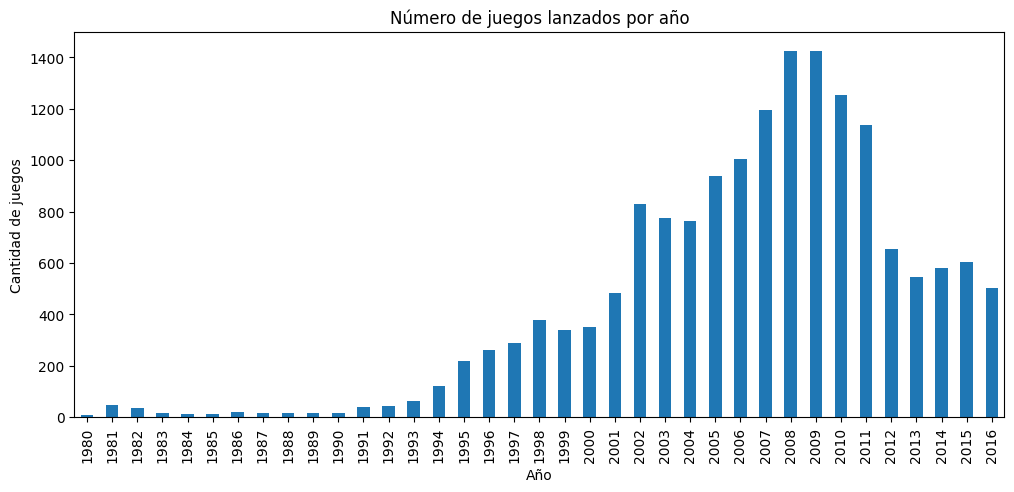

In [71]:


plt.figure(figsize=(12,5))
games_per_year.plot(kind='bar')
plt.title('Número de juegos lanzados por año')
plt.xlabel('Año')
plt.ylabel('Cantidad de juegos')
plt.show()


Los datos anteriores a 2000 no son confiables para análisis estadísticos porque el número de juegos es demasiado bajo.
El período 2000–2016 es el más representativo.
Para construir modelos sobre 2017 (como pide el proyecto), lo mejor es usar un período reciente con datos completos

In [72]:



# Ventas totales por plataforma
platform_sales = df.groupby('platform')['total_sales'].sum().sort_values(ascending=False)


platform_sales.head(10)



platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
PS       730.86
GBA      317.85
PS4      314.14
PSP      294.05
PC       259.52
Name: total_sales, dtype: float64

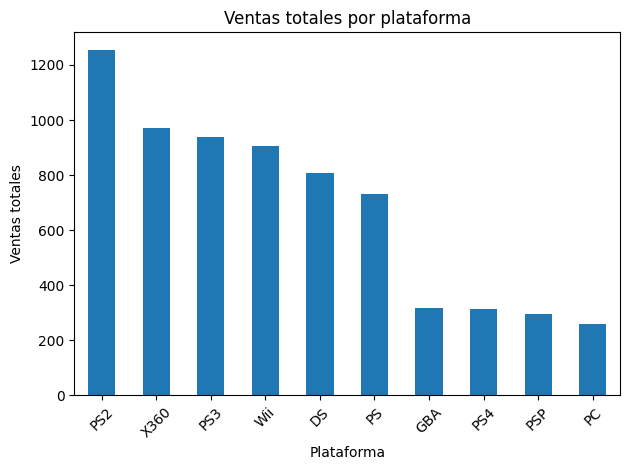

In [73]:
# se anexa grafica 

plt.figure()
platform_sales.head(10).plot(kind='bar')
plt.xlabel("Plataforma")
plt.ylabel("Ventas totales")
plt.title("Ventas totales por plataforma")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [74]:
top_platforms = platform_sales.head(5).index
top_platforms

Index(['PS2', 'X360', 'PS3', 'Wii', 'DS'], dtype='object', name='platform')

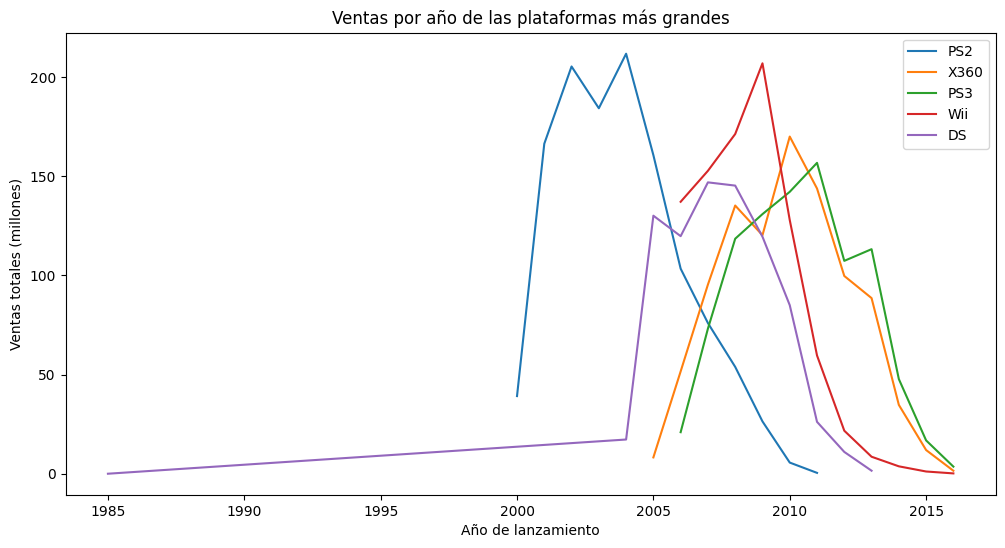

In [75]:




plt.figure(figsize=(12,6))

for platform in top_platforms:
    sales_by_year = df[df['platform'] == platform].groupby('year_of_release')['total_sales'].sum()
    plt.plot(sales_by_year.index, sales_by_year.values, label=platform)

plt.title('Ventas por año de las plataformas más grandes')
plt.xlabel('Año de lanzamiento')
plt.ylabel('Ventas totales (millones)')
plt.legend()
plt.show()





Para el modelo tomé los datos del período 2013–2016.
Elegí este rango porque:

Los años anteriores a 2000 contienen muy pocos juegos y no aportan información representativa.

Al analizar las ventas por plataforma observé que los ciclos de vida son de aproximadamente 7–10 años.

Las plataformas relevantes en 2016 (PS4, Xbox One, 3DS, PC) comenzaron a generar datos útiles desde alrededor de 2013.

Incluir datos muy antiguos agregaría ruido porque corresponden a plataformas que ya no existen.

Aunque 2016 tiene algunos valores faltantes, sigue siendo un año útil y forma parte de la tendencia reciente.

Por lo tanto, para construir un modelo válido para 2017 es apropiado usar únicamente los datos del período 2013–2016, que reflejan las condiciones actuales del mercado.

In [76]:
df_recent = df[df['year_of_release'].between(2013, 2016)]
df_recent.shape

(2233, 12)

EMEPEZAMOS A TRABAJAR CON EL DF_RECENT datos del 2013 al 2016

platform_sales = ventas de este periodo

In [77]:
platform_sales = df_recent.groupby('platform')['total_sales'].sum().sort_values(ascending=False)
platform_sales

platform
PS4     314.14
PS3     181.43
XOne    159.32
3DS     143.25
X360    136.80
WiiU     64.63
PC       39.43
PSV      32.99
Wii      13.66
PSP       3.50
DS        1.54
Name: total_sales, dtype: float64

AQUI TRABAJAMOS CON EL TOP 5 DE JUEGOS DEL 2013 AL 2016

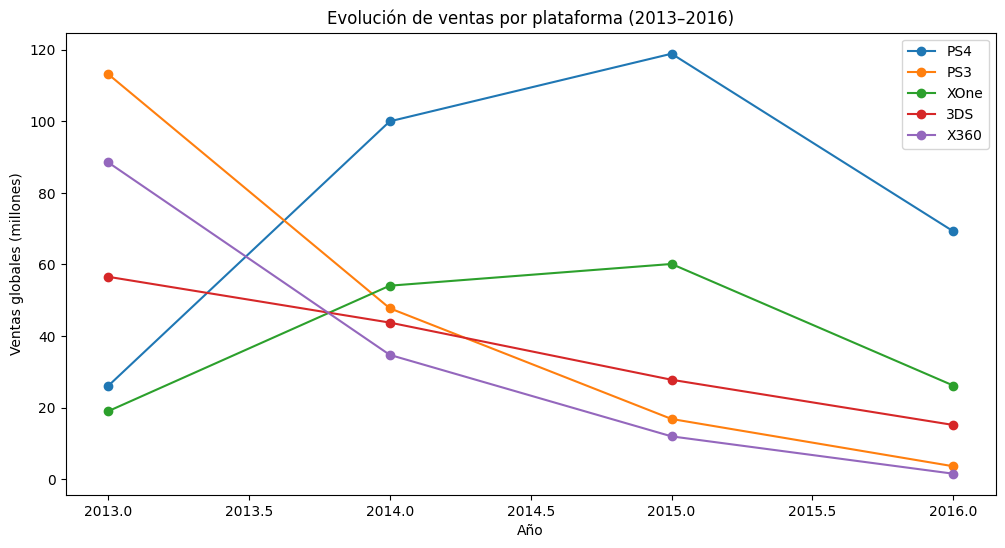

In [78]:

top_platforms = platform_sales.head(5).index

plt.figure(figsize=(12,6))
for p in top_platforms:
    temp = df_recent[df_recent['platform'] == p].groupby('year_of_release')['total_sales'].sum()
    plt.plot(temp.index, temp.values, marker='o', label=p)

plt.title('Evolución de ventas por plataforma (2013–2016)')
plt.xlabel('Año')
plt.ylabel('Ventas globales (millones)')
plt.legend()
plt.show()

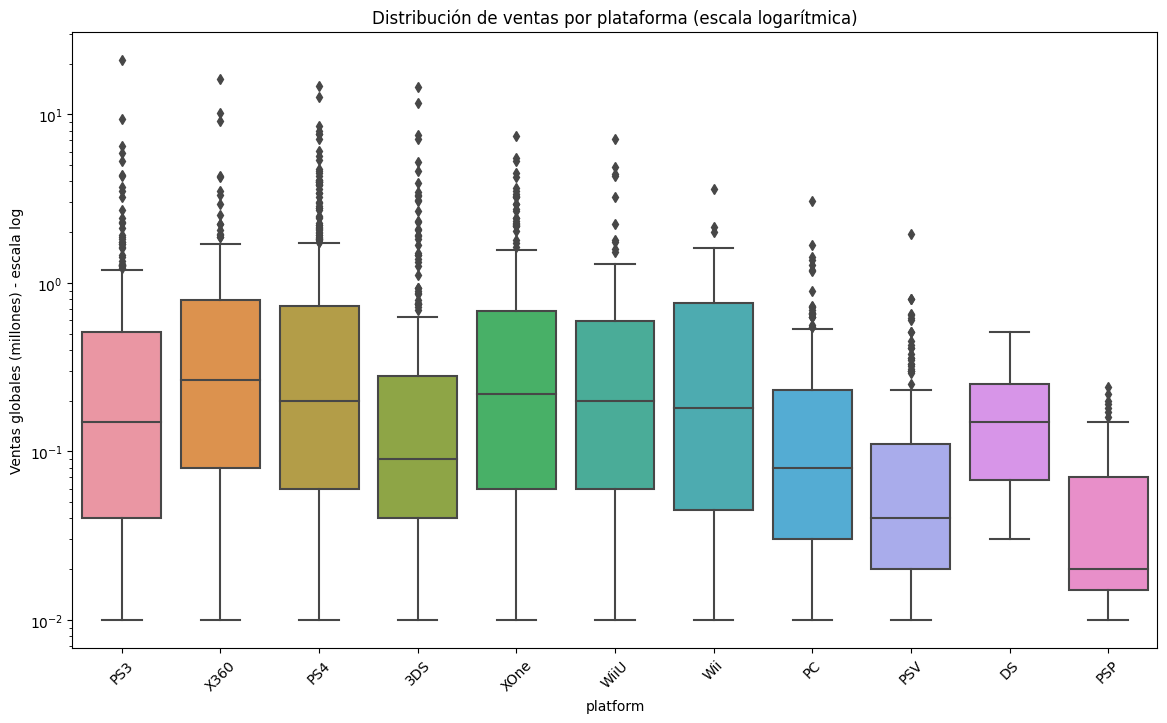

In [79]:

plt.figure(figsize=(14,8))
sns.boxplot(data=df_recent, x='platform', y='total_sales')
plt.yscale('log')
plt.xticks(rotation=45)
plt.title('Distribución de ventas por plataforma (escala logarítmica)')
plt.ylabel('Ventas globales (millones) - escala log')
plt.show()


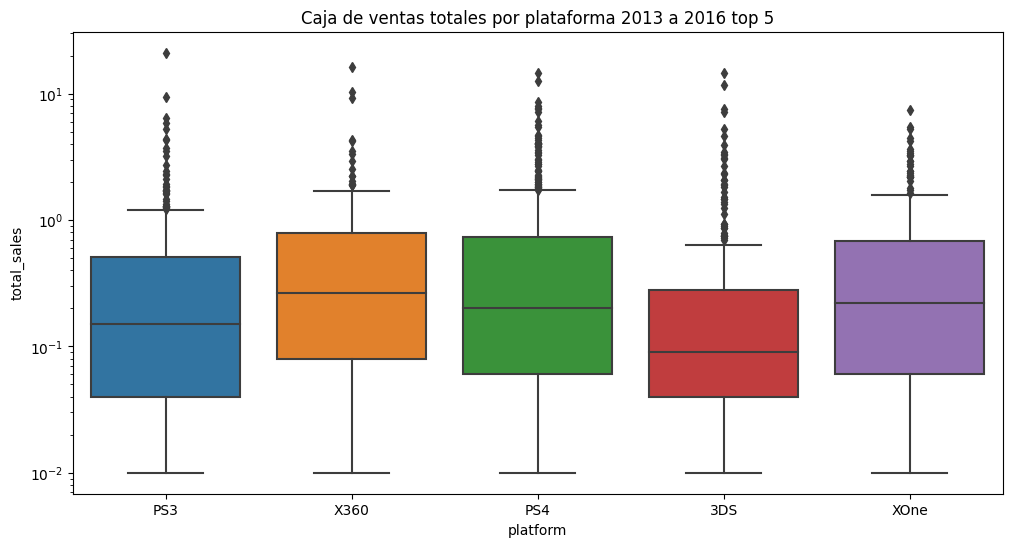

,mean,median,std,count
platform,,,,
PS4,0.801378,0.20,1.609456,392
PS3,0.705973,0.27,1.391749,1331
XOne,0.645020,0.22,1.036139,247
3DS,0.498077,0.12,1.430876,520
X360,0.769746,0.28,1.615674,1262


In [80]:


plt.figure(figsize=(12,6))
sns.boxplot(data=df_recent[df_recent['platform'].isin(top_platforms)], x='platform', y='total_sales')
plt.yscale('log')  
plt.title('Caja de ventas totales por plataforma 2013 a 2016 top 5')
plt.show()

# Estadísticas por plataforma
df.groupby('platform')['total_sales'].agg(['mean','median','std','count']).loc[top_platforms]


Las diferencias entre plataformas son claras y estadísticamente significativas.
Las plataformas con mayor rendimiento en ventas son PS4 y XOne.
Plataformas en declive como PS3, X360 y WiiU muestran ventas bajas y alta dispersión.
PC es estable, pero con ventas promedio relativamente bajas.
Hayjuegos excepcionales que elevan mucho las ventas de ciertas plataformas

In [81]:
# User Score: reemplazar tbd -> NaN y convertir a float
df['user_score'] = df['user_score'].replace('tbd', np.nan)
df['user_score'] = pd.to_numeric(df['user_score'], errors='coerce')

# Critic Score: convertir a float si no lo está
df['critic_score'] = pd.to_numeric(df['critic_score'], errors='coerce')

In [82]:
ps4 = df[df['platform'] == 'PS4'][['critic_score','user_score','total_sales']].dropna()

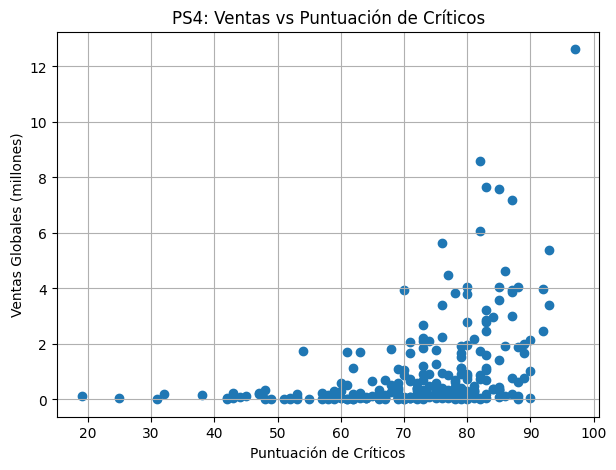

In [83]:

plt.figure(figsize=(7,5))
plt.scatter(ps4['critic_score'], ps4['total_sales'])
plt.title('PS4: Ventas vs Puntuación de Críticos')
plt.xlabel('Puntuación de Críticos')
plt.ylabel('Ventas Globales (millones)')
plt.grid(True)
plt.show()


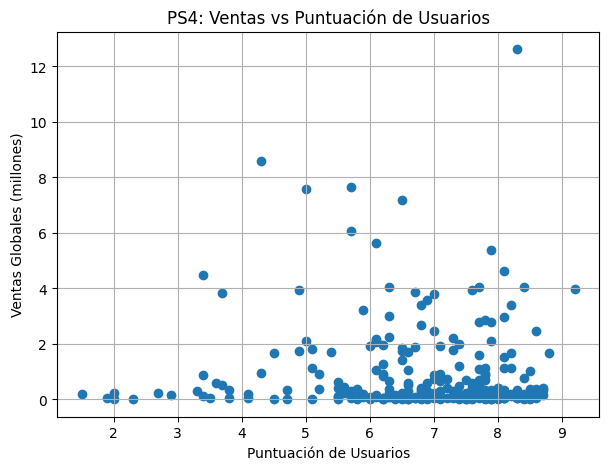

In [84]:
plt.figure(figsize=(7,5))
plt.scatter(ps4['user_score'], ps4['total_sales'])
plt.title('PS4: Ventas vs Puntuación de Usuarios')
plt.xlabel('Puntuación de Usuarios')
plt.ylabel('Ventas Globales (millones)')
plt.grid(True)
plt.show()

In [85]:

ps4_clean = ps4.dropna(subset=['critic_score', 'user_score', 'total_sales']).copy()

# Convertimos a float por seguridad
ps4_clean['critic_score'] = ps4_clean['critic_score'].astype(float)
ps4_clean['user_score'] = ps4_clean['user_score'].astype(float)

print("Registros con datos completos:", len(ps4_clean))

print("Correlación PS4 (critic → ventas):", 
      ps4_clean['critic_score'].corr(ps4_clean['total_sales']))

print("Correlación PS4 (user → ventas):", 
      ps4_clean['user_score'].corr(ps4_clean['total_sales']))


Registros con datos completos: 249
Correlación PS4 (critic → ventas): 0.40589480145836687
Correlación PS4 (user → ventas): -0.03362497596528878


In [86]:

same_games = df_recent.groupby('name')['total_sales'].sum().sort_values(ascending=False).head(20)
same_games.head()


name
Grand Theft Auto V                56.58
Call of Duty: Ghosts              27.39
Call of Duty: Black Ops 3         25.67
Minecraft                         24.16
Call of Duty: Advanced Warfare    21.97
Name: total_sales, dtype: float64

In [87]:
top_games = same_games.index.tolist()

df_top_games = df_recent[df_recent['name'].isin(top_games)]

In [88]:
pivot_games = df_top_games.pivot_table(
    index='name',
    columns='platform',
    values='total_sales',
    aggfunc='sum'
).fillna(0)

pivot_games.head()

platform,3DS,DS,PC,PS3,PS4,PSP,PSV,Wii,WiiU,X360,XOne
name,,,,,,,,,,,
Assassin's Creed IV: Black Flag,0.0,0.0,0.65,3.71,2.86,0.0,0.0,0.0,0.29,3.31,2.24
Battlefield 4,0.0,0.0,1.36,3.49,3.58,0.0,0.0,0.0,0.00,3.49,2.02
Call of Duty: Advanced Warfare,0.0,0.0,0.41,4.36,7.66,0.0,0.0,0.0,0.00,4.28,5.26
Call of Duty: Black Ops 3,0.0,0.0,0.26,1.69,14.63,0.0,0.0,0.0,0.00,1.70,7.39
Call of Duty: Ghosts,0.0,0.0,0.69,9.36,3.83,0.0,0.0,0.0,0.35,10.24,2.92


In [89]:
games_to_plot = [
    'Grand Theft Auto V',
    'Call of Duty: Black Ops 3',
    'Minecraft',
    'FIFA 16',
    'Battlefield 4'
]

pivot_plot = pivot_games.loc[games_to_plot]

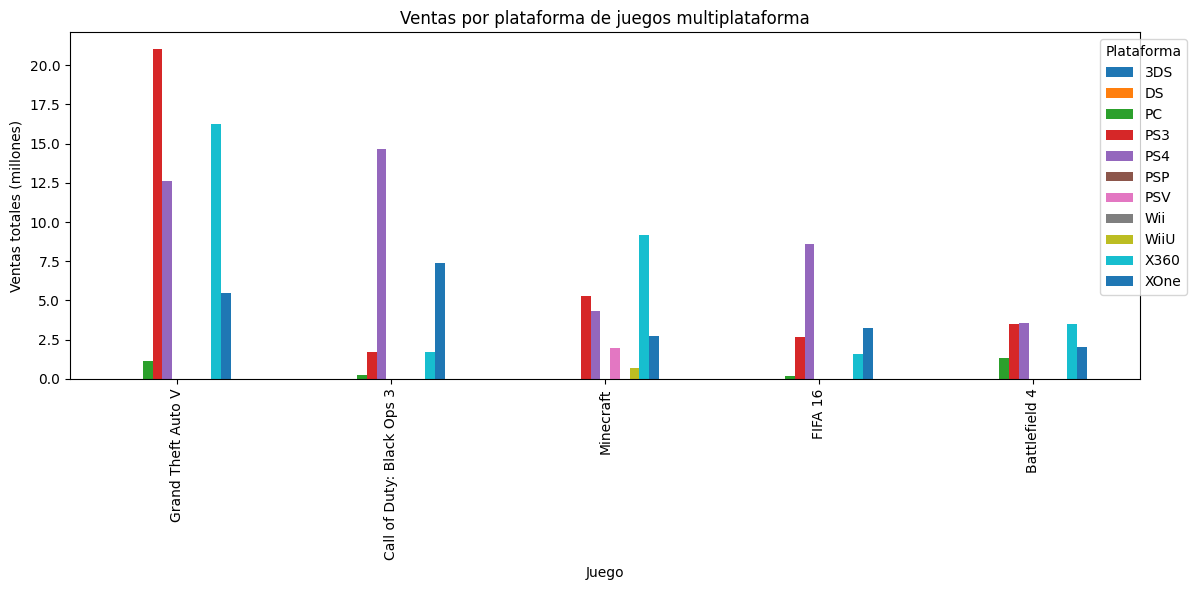

In [90]:
pivot_plot.plot(
    kind='bar',
    figsize=(12,6)
)

plt.title('Ventas por plataforma de juegos multiplataforma')
plt.xlabel('Juego')
plt.ylabel('Ventas totales (millones)')
plt.legend(title='Plataforma', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [91]:



genre_avg_sales = (
    df_recent
    .groupby('genre')['total_sales']
    .mean()
    .sort_values(ascending=False)
)

genre_avg_sales



genre
Shooter         1.245882
Sports          0.703972
Platform        0.576081
Role-Playing    0.499623
Racing          0.469294
Fighting        0.441375
Action          0.420196
Misc            0.405290
Simulation      0.350968
Puzzle          0.186471
Strategy        0.180000
Adventure       0.096490
Name: total_sales, dtype: float64

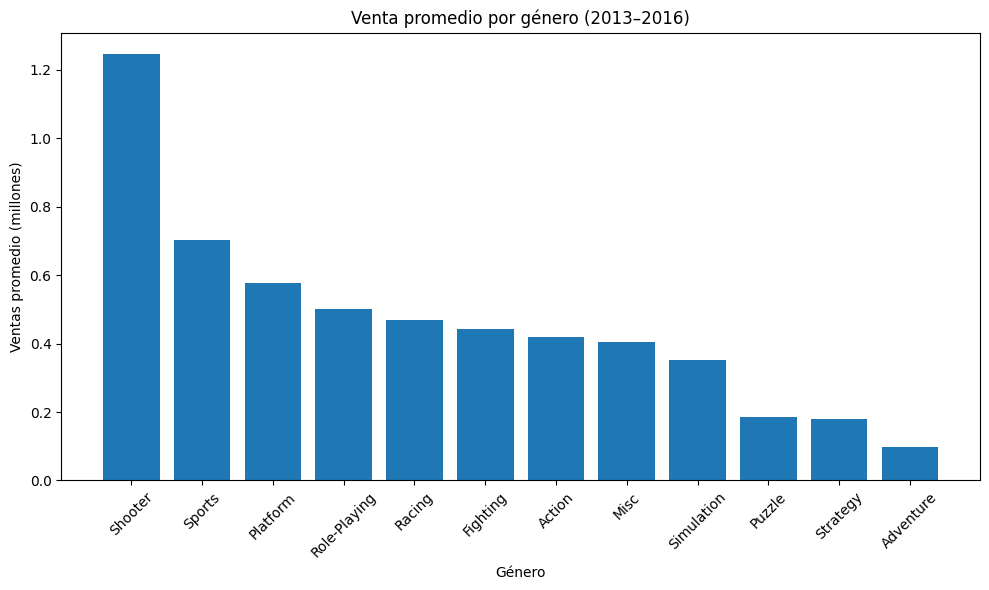

In [92]:

plt.figure(figsize=(10,6))
plt.bar(genre_avg_sales.index, genre_avg_sales.values)
plt.title('Venta promedio por género (2013–2016)')
plt.ylabel('Ventas promedio (millones)')
plt.xlabel('Género')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



Paso 4. Crea un perfil de usuario para cada región

In [93]:
regions = {
    'na_sales': 'Norteamérica',
    'eu_sales': 'Europa',
    'jp_sales': 'Japón'
}

for region, name in regions.items():
    print(f'\nTop 5 plataformas en {name}')
    print(
        df.groupby('platform')[region]
          .sum()
          .sort_values(ascending=False)
          .head(5)
    )



Top 5 plataformas en Norteamérica
platform
X360    602.47
PS2     583.84
Wii     496.90
PS3     393.49
DS      382.40
Name: na_sales, dtype: float64

Top 5 plataformas en Europa
platform
PS2     339.29
PS3     330.29
X360    270.76
Wii     262.21
PS      213.61
Name: eu_sales, dtype: float64

Top 5 plataformas en Japón
platform
DS      175.57
PS      139.82
PS2     139.20
SNES    116.55
3DS     100.67
Name: jp_sales, dtype: float64


In [94]:
for region, name in regions.items():
    print(f'\nTop 5 géneros en {name}')
    print(
        df.groupby('genre')[region]
          .sum()
          .sort_values(ascending=False)
          .head(5)
    )


Top 5 géneros en Norteamérica
genre
Action      879.01
Sports      684.43
Shooter     592.24
Platform    445.50
Misc        407.27
Name: na_sales, dtype: float64

Top 5 géneros en Europa
genre
Action     519.13
Sports     376.79
Shooter    317.34
Racing     236.51
Misc       212.74
Name: eu_sales, dtype: float64

Top 5 géneros en Japón
genre
Role-Playing    355.41
Action          161.43
Sports          135.54
Platform        130.83
Misc            108.11
Name: jp_sales, dtype: float64


<Figure size 1000x600 with 0 Axes>

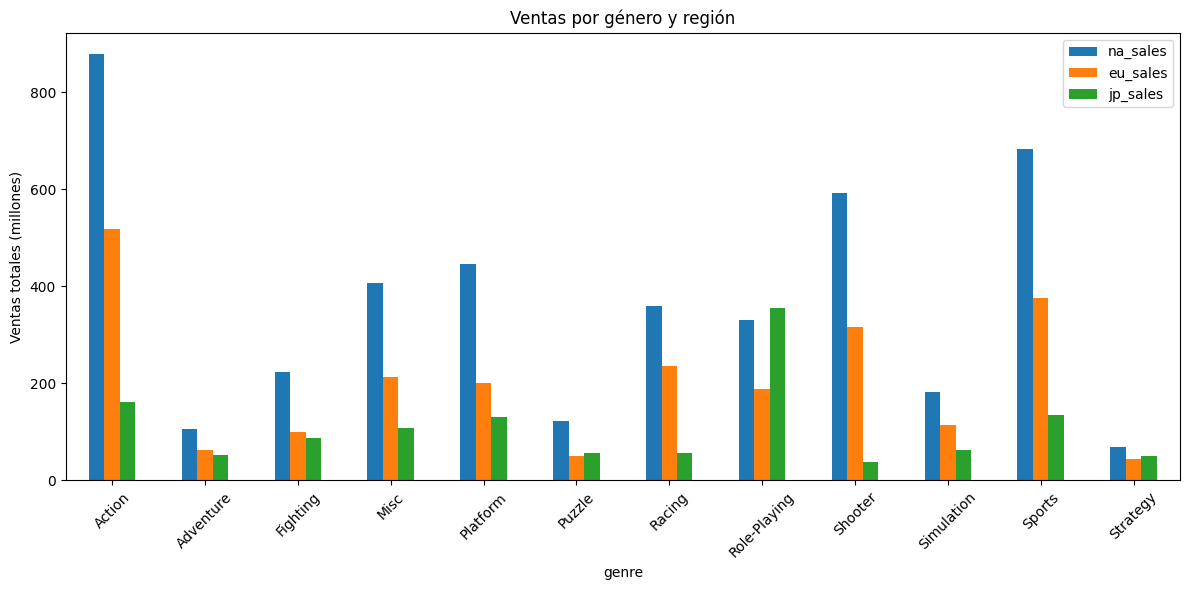

In [95]:
plt.figure(figsize=(10,6))

genre_region = (
    df.groupby('genre')[['na_sales','eu_sales','jp_sales']]
      .sum()
)

genre_region.plot(kind='bar', figsize=(12,6))
plt.title('Ventas por género y región')
plt.ylabel('Ventas totales (millones)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [96]:
rating_region_avg = (
    df.groupby('rating')[['na_sales','eu_sales','jp_sales']]
      .mean()
      .sort_values(by='na_sales', ascending=False)
)

rating_region_avg

,na_sales,eu_sales,jp_sales
rating,,,
AO,1.260000,0.610000,0.000000
K-A,0.853333,0.090000,0.486667
M,0.478874,0.309642,0.041100
E,0.324058,0.178008,0.049652
T,0.256586,0.144218,0.051131
E10+,0.248817,0.132761,0.028310
EC,0.191250,0.013750,0.000000
RP,0.000000,0.026667,0.000000


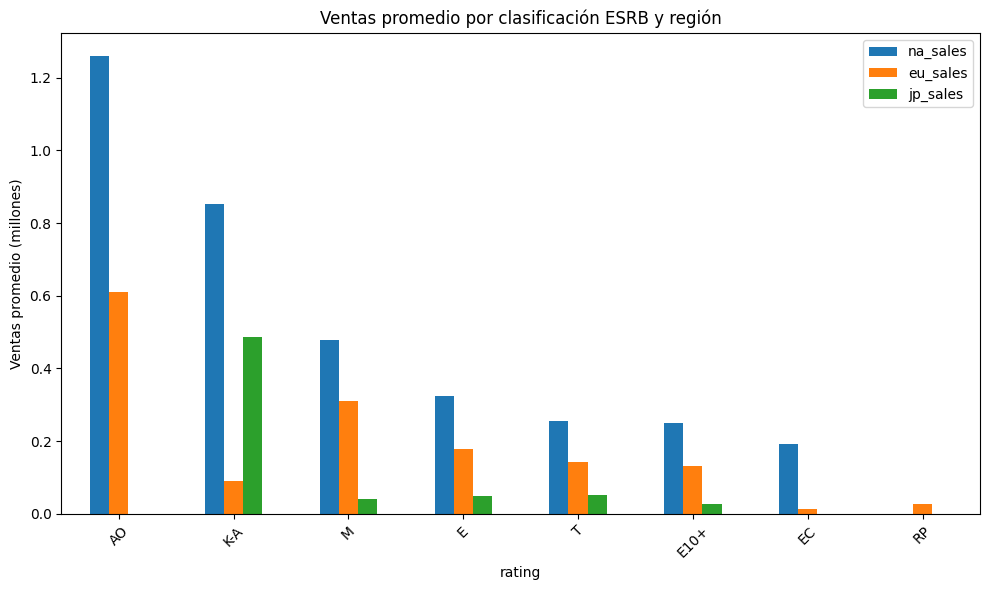

In [97]:
rating_region_avg.plot(kind='bar', figsize=(10,6))
plt.title('Ventas promedio por clasificación ESRB y región')
plt.ylabel('Ventas promedio (millones)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

El comportamiento de los usuarios varía significativamente entre regiones.
Norteamérica y Europa muestran patrones similares en plataformas y géneros, mientras que Japón presenta preferencias claramente distintas, tanto en plataformas como en tipos de juegos.
Por ello, las estrategias de lanzamiento y marketing deben adaptarse a cada región.

El análisis de las clasificaciones ESRB muestra que su impacto en las ventas varía según la región. En Norteamérica y Europa, los juegos clasificados como M y T presentan mayores ventas promedio, lo que indica una mayor aceptación de títulos dirigidos a públicos adolescentes y adultos. En Japón, la diferencia entre clasificaciones es menos marcada, lo que sugiere que el rating ESRB tiene una menor influencia en las ventas en comparación con otros factores como el género o la plataforma.

Paso 5. Prueba las siguientes hipótesis:

In [98]:
xone_scores = df[df['platform'] == 'XOne']['user_score'].dropna()
pc_scores = df[df['platform'] == 'PC']['user_score'].dropna()
alpha = 0.05

test_1 = ttest_ind(xone_scores, pc_scores, equal_var=False)

print('p-value:', test_1.pvalue)

if test_1.pvalue < alpha:
    print('Se rechaza H₀: las medias son diferentes')
else:
    print('No se rechaza H₀: no hay diferencia significativa')

p-value: 4.935072360183574e-06
Se rechaza H₀: las medias son diferentes


Dado que el p-value es mucho menor que 0.05, se rechaza la hipótesis nula.

Existe una diferencia estadísticamente significativa entre las calificaciones promedio de los usuarios en las plataformas Xbox One (XOne) y PC.

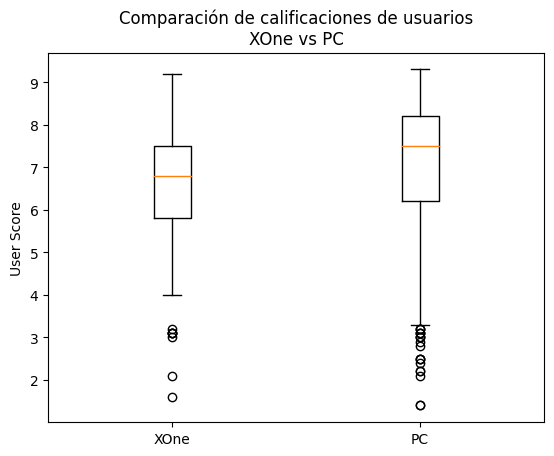

In [99]:

# Filtrar datos
xone_scores = df[df['platform'] == 'XOne']['user_score'].dropna()
pc_scores = df[df['platform'] == 'PC']['user_score'].dropna()

# Boxplot
plt.figure()
plt.boxplot([xone_scores, pc_scores], labels=['XOne', 'PC'])
plt.title('Comparación de calificaciones de usuarios\nXOne vs PC')
plt.ylabel('User Score')
plt.show()

Tanto el análisis gráfico como la prueba estadística muestran que las calificaciones promedio de los usuarios difieren entre las plataformas XOne y PC. PC presenta una mediana más alta y una mayor dispersión en las calificaciones, lo que sugiere una percepción más favorable por parte de los usuarios en comparación con XOne.

In [100]:
#Filtrar calificaciones por género
action_scores = df[df['genre'] == 'Action']['user_score'].dropna()
sports_scores = df[df['genre'] == 'Sports']['user_score'].dropna()

In [101]:
from scipy.stats import ttest_ind

test_genres = ttest_ind(action_scores, sports_scores, equal_var=False)

print('p-value:', test_genres.pvalue)

if test_genres.pvalue < alpha:
    print('Se rechaza H₀: las medias son diferentes')
else:
    print('No se rechaza H₀: no hay diferencia significativa')

p-value: 0.11483818791498286
No se rechaza H₀: no hay diferencia significativa


Conclusiones Generales:
Los datos muestran que las ventas cambian mucho según la plataforma, el año y la región. En el período más reciente, PS4 y Xbox One son las plataformas más fuertes, mientras que otras como PS3 y Xbox 360 ya van en bajada.

Las reseñas de críticos sí tienen relación con las ventas, pero las calificaciones de los usuarios casi no influyen. También se ve que cada región tiene gustos distintos, sobre todo Japón frente a NA y UE.

Las pruebas de hipótesis confirmaron que hay diferencias reales en las calificaciones promedio entre plataformas y géneros.

En general, para 2017 conviene enfocarse en plataformas actuales y géneros populares, ya que son los que tienen más probabilidad de vender bien.

